In [8]:
# Download GloVe 6B 100d into the current folder (/content)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.100d.txt
!ls

glove.6B.100d.txt  sample_data	training.csv
glove.6B.zip	   test.csv	validation.csv


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(42)
np.random_seed = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        tokens = text.lower().split()
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

        if len(indices) < self.max_len:
            indices += [self.vocab['<PAD>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

In [11]:
def load_glove_embeddings(glove_path, embedding_dim=100):
    print(f"Loading GloVe embeddings from {glove_path}...")
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

In [12]:
def build_vocab_and_embeddings(texts, glove_embeddings, embedding_dim=100):
    print("Building vocabulary...")
    word_freq = Counter()
    for text in texts:
        tokens = text.lower().split()
        word_freq.update(tokens)

    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word in word_freq:
        vocab[word] = idx
        idx += 1

    vocab_size = len(vocab)
    embedding_matrix = np.random.randn(vocab_size, embedding_dim).astype(np.float32) * 0.01
    embedding_matrix[0] = np.zeros(embedding_dim)

    found = 0
    for word, idx in vocab.items():
        if word in glove_embeddings:
            embedding_matrix[idx] = glove_embeddings[word]
            found += 1

    print(f"Vocabulary size: {vocab_size}")
    print(f"Found {found}/{vocab_size} words in GloVe")

    return vocab, embedding_matrix

In [13]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'confusion_matrix': cm
    }

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} Results:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")

    print("\nPer-class metrics:")
    emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    for i, emotion in enumerate(emotion_names):
        print(f"  {emotion:10s}: P={metrics['per_class_precision'][i]:.4f}, "
              f"R={metrics['per_class_recall'][i]:.4f}, F1={metrics['per_class_f1'][i]:.4f}")

    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        return self.fc(dropped)

In [15]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        concat = torch.cat([forward_hidden, backward_hidden], dim=1)
        return self.fc(self.dropout(concat))


class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, hidden = self.rnn(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        concat = torch.cat([forward_hidden, backward_hidden], dim=1)
        return self.fc(self.dropout(concat))

In [16]:
class BiLSTMWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix,
                 dropout=0.5, attention_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention_W = nn.Linear(hidden_dim * 2, attention_dim)
        self.attention_v = nn.Linear(attention_dim, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, return_attention=False):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        e_t = self.attention_v(torch.tanh(self.attention_W(lstm_out)))
        attention_weights = torch.softmax(e_t, dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)
        out = self.fc(self.dropout(context))

        if return_attention:
            return out, attention_weights.squeeze(-1)
        return out

In [17]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, hidden_dim,
                 num_classes, max_len, embedding_matrix=None, dropout=0.1):
        super().__init__()

        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.pos_embedding = nn.Parameter(torch.randn(max_len, embedding_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embedding_dim)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        seq_len = x.size(1)
        embedded = embedded + self.pos_embedding[:seq_len, :].unsqueeze(0)

        padding_mask = (x == 0)
        encoder_output = self.transformer_encoder(embedded, src_key_padding_mask=padding_mask)

        mask_expanded = (~padding_mask).unsqueeze(-1).float()
        sum_output = (encoder_output * mask_expanded).sum(dim=1)
        lengths = mask_expanded.sum(dim=1).clamp(min=1)
        pooled = sum_output / lengths

        pooled = self.layer_norm(pooled)
        pooled = self.dropout(pooled)
        return self.fc(pooled)

In [18]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(dataloader)
    return metrics

In [19]:
def train_model(model, train_loader, dev_loader, criterion, optimizer, num_epochs, model_name):
    print(f"\nTraining {model_name}...")
    print("=" * 60)

    best_dev_f1 = 0

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        train_metrics = evaluate(model, train_loader, criterion, device)
        dev_metrics = evaluate(model, dev_loader, criterion, device)

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f} | "
              f"Dev Acc: {dev_metrics['accuracy']:.4f} | Dev F1: {dev_metrics['macro_f1']:.4f} | "
              f"Time: {epoch_time:.2f}s")

        if dev_metrics['macro_f1'] > best_dev_f1:
            best_dev_f1 = dev_metrics['macro_f1']
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ", "_")}_best.pt')

    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ", "_")}_best.pt'))
    print(f"\nBest Dev F1: {best_dev_f1:.4f}")
    return model

In [20]:
def plot_attention_heatmap(words, attn, title="Attention Heatmap"):
    attn = np.array(attn)[None, :]  # (1, seq_len)

    plt.figure(figsize=(min(14, len(words)), 2.5))
    plt.imshow(attn, aspect="auto", cmap='hot')
    plt.xticks(range(len(words)), words, rotation=45, ha='right')
    plt.yticks([])
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [21]:
def get_example_from_loader(model, data_loader, device, idx2word,
                            want_correct=True, max_batches=50):
    model.eval()
    with torch.no_grad():
        for b_i, batch in enumerate(data_loader):
            if b_i >= max_batches:
                break

            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits, attn = model(inputs, return_attention=True)
            preds = logits.argmax(dim=1)

            mask = (preds == labels) if want_correct else (preds != labels)

            if mask.any():
                idx = mask.nonzero(as_tuple=True)[0][0].item()

                sent_ids = inputs[idx].cpu().tolist()
                attn_weights = attn[idx].cpu().tolist()

                true_label = labels[idx].item()
                pred_label = preds[idx].item()

                words, weights = [], []
                for tid, w in zip(sent_ids, attn_weights):
                    if tid == PAD_IDX:
                        continue
                    words.append(idx2word.get(tid, "<UNK>"))
                    weights.append(w)

                return {
                    "words": words,
                    "attn": weights,
                    "true_label": true_label,
                    "pred_label": pred_label,
                }

    return None

In [22]:
train_df = pd.read_csv('training.csv')
dev_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

print(f"Train size: {len(train_df)}")
print(f"Dev size: {len(dev_df)}")
print(f"Test size: {len(test_df)}")


Train size: 16000
Dev size: 2000
Test size: 2000


In [23]:
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt', embedding_dim=100)

vocab, embedding_matrix = build_vocab_and_embeddings(
    train_df['text'].tolist(), glove_embeddings, embedding_dim=100
)

max_len = 50
batch_size = 32

train_dataset = EmotionDataset(train_df['text'].tolist(), train_df['label'].tolist(), vocab, max_len)
dev_dataset = EmotionDataset(dev_df['text'].tolist(), dev_df['label'].tolist(), vocab, max_len)
test_dataset = EmotionDataset(test_df['text'].tolist(), test_df['label'].tolist(), vocab, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

criterion = nn.CrossEntropyLoss()

Loading GloVe embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors
Building vocabulary...
Vocabulary size: 15214
Found 14212/15214 words in GloVe


In [24]:
print("\n--- LSTM ---")
lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=64,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.2
).to(device)

optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3)
#optimizer = optim.SGD(lstm_model.parameters(),lr=1e-2,momentum=0.9)
lstm_model = train_model(
    lstm_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="LSTM"
)


--- LSTM ---

Training LSTM...
Epoch 1/15 | Train Loss: 1.5900 | Train Acc: 0.3351 | Train F1: 0.0837 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.61s
Epoch 2/15 | Train Loss: 1.5785 | Train Acc: 0.3356 | Train F1: 0.0843 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 2.37s
Epoch 3/15 | Train Loss: 1.5773 | Train Acc: 0.3377 | Train F1: 0.0961 | Dev Acc: 0.3510 | Dev F1: 0.0913 | Time: 2.43s
Epoch 4/15 | Train Loss: 1.5731 | Train Acc: 0.3401 | Train F1: 0.1013 | Dev Acc: 0.3510 | Dev F1: 0.0881 | Time: 2.43s
Epoch 5/15 | Train Loss: 1.5816 | Train Acc: 0.3362 | Train F1: 0.0858 | Dev Acc: 0.3520 | Dev F1: 0.0880 | Time: 2.70s
Epoch 6/15 | Train Loss: 1.5755 | Train Acc: 0.3392 | Train F1: 0.0938 | Dev Acc: 0.3510 | Dev F1: 0.0884 | Time: 2.59s
Epoch 7/15 | Train Loss: 1.5585 | Train Acc: 0.3373 | Train F1: 0.0872 | Dev Acc: 0.3515 | Dev F1: 0.0868 | Time: 2.34s
Epoch 8/15 | Train Loss: 1.5182 | Train Acc: 0.3387 | Train F1: 0.0910 | Dev Acc: 0.3520 | Dev F1: 0.0880 | Time: 2.27s
Epoch 9/

In [25]:
print("\nLSTM - Development Set:")
lstm_dev_metrics = evaluate(lstm_model, dev_loader, criterion, device)
print_metrics(lstm_dev_metrics, "LSTM Dev")


LSTM - Development Set:

LSTM Dev Results:
Accuracy: 0.8535
Macro Precision: 0.7515
Macro Recall: 0.7610
Macro F1: 0.7510

Per-class metrics:
  sadness   : P=0.9711, R=0.9164, F1=0.9429
  joy       : P=0.9141, R=0.9219, F1=0.9180
  love      : P=0.6259, R=0.4888, F1=0.5489
  anger     : P=0.9490, R=0.8800, F1=0.9132
  fear      : P=0.7099, R=0.8774, F1=0.7848
  surprise  : P=0.3391, R=0.4815, F1=0.3980

Confusion Matrix:
[[504  17   3   8  15   3]
 [  6 649  40   1   3   5]
 [  2  32  87   0   4  53]
 [  1   3   1 242  27   1]
 [  4   3   2   3 186  14]
 [  2   6   6   1  27  39]]


In [26]:
print("\nLSTM - Test Set:")
lstm_test_metrics = evaluate(lstm_model, test_loader, criterion, device)
print_metrics(lstm_test_metrics, "LSTM Test")


LSTM - Test Set:

LSTM Test Results:
Accuracy: 0.8595
Macro Precision: 0.7485
Macro Recall: 0.7566
Macro F1: 0.7485

Per-class metrics:
  sadness   : P=0.9797, R=0.9122, F1=0.9447
  joy       : P=0.8975, R=0.9194, F1=0.9083
  love      : P=0.6212, R=0.5157, F1=0.5636
  anger     : P=0.9331, R=0.8618, F1=0.8960
  fear      : P=0.7519, R=0.9062, F1=0.8219
  surprise  : P=0.3077, R=0.4242, F1=0.3567

Confusion Matrix:
[[530  25   2  11  10   3]
 [  6 639  38   2   1   9]
 [  1  36  82   2   0  38]
 [  1   5   0 237  31   1]
 [  3   2   3   1 203  12]
 [  0   5   7   1  25  28]]


In [27]:
print("\n--- BiLSTM ---")
bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=64,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.2
).to(device)
optimizer = optim.Adam(bilstm_model.parameters(), lr=1e-3)
#optimizer = optim.SGD(bilstm_model.parameters(),lr=1e-2,momentum=0.9)
bilstm_model = train_model(
    bilstm_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="BiLSTM"
)


--- BiLSTM ---

Training BiLSTM...
Epoch 1/15 | Train Loss: 1.2028 | Train Acc: 0.7913 | Train F1: 0.6200 | Dev Acc: 0.7785 | Dev F1: 0.5909 | Time: 2.90s
Epoch 2/15 | Train Loss: 0.3827 | Train Acc: 0.9372 | Train F1: 0.9003 | Dev Acc: 0.9145 | Dev F1: 0.8756 | Time: 2.56s
Epoch 3/15 | Train Loss: 0.1883 | Train Acc: 0.9531 | Train F1: 0.9295 | Dev Acc: 0.9200 | Dev F1: 0.8898 | Time: 2.57s
Epoch 4/15 | Train Loss: 0.1276 | Train Acc: 0.9663 | Train F1: 0.9493 | Dev Acc: 0.9195 | Dev F1: 0.8910 | Time: 2.54s
Epoch 5/15 | Train Loss: 0.0912 | Train Acc: 0.9693 | Train F1: 0.9554 | Dev Acc: 0.9235 | Dev F1: 0.8983 | Time: 3.20s
Epoch 6/15 | Train Loss: 0.0712 | Train Acc: 0.9808 | Train F1: 0.9711 | Dev Acc: 0.9220 | Dev F1: 0.8901 | Time: 2.54s
Epoch 7/15 | Train Loss: 0.0583 | Train Acc: 0.9801 | Train F1: 0.9678 | Dev Acc: 0.9180 | Dev F1: 0.8914 | Time: 2.56s
Epoch 8/15 | Train Loss: 0.0461 | Train Acc: 0.9895 | Train F1: 0.9829 | Dev Acc: 0.9225 | Dev F1: 0.8941 | Time: 2.55s
Epoc

In [28]:
print("\nBiLSTM - Development Set:")
bilstm_dev_metrics = evaluate(bilstm_model, dev_loader, criterion, device)
print_metrics(bilstm_dev_metrics, "BiLSTM Dev")


BiLSTM - Development Set:

BiLSTM Dev Results:
Accuracy: 0.9235
Macro Precision: 0.8827
Macro Recall: 0.9192
Macro F1: 0.8983

Per-class metrics:
  sadness   : P=0.9611, R=0.9436, F1=0.9523
  joy       : P=0.9740, R=0.9062, F1=0.9389
  love      : P=0.7692, R=0.9551, F1=0.8521
  anger     : P=0.9164, R=0.9564, F1=0.9359
  fear      : P=0.9118, R=0.8774, F1=0.8942
  surprise  : P=0.7634, R=0.8765, F1=0.8161

Confusion Matrix:
[[519   4   5  12   9   1]
 [  7 638  46   4   3   6]
 [  0   6 170   2   0   0]
 [  7   1   0 263   3   1]
 [  6   0   0   6 186  14]
 [  1   6   0   0   3  71]]


In [29]:
print("\nBiLSTM - Test Set:")
bilstm_test_metrics = evaluate(bilstm_model, test_loader, criterion, device)
print_metrics(bilstm_test_metrics, "BiLSTM Test")


BiLSTM - Test Set:

BiLSTM Test Results:
Accuracy: 0.9125
Macro Precision: 0.8562
Macro Recall: 0.9029
Macro F1: 0.8752

Per-class metrics:
  sadness   : P=0.9615, R=0.9449, F1=0.9531
  joy       : P=0.9719, R=0.8964, F1=0.9326
  love      : P=0.7062, R=0.9371, F1=0.8054
  anger     : P=0.9036, R=0.9200, F1=0.9117
  fear      : P=0.9028, R=0.8705, F1=0.8864
  surprise  : P=0.6914, R=0.8485, F1=0.7619

Confusion Matrix:
[[549   6   1  15   9   1]
 [  4 623  58   3   0   7]
 [  0   7 149   2   0   1]
 [  8   3   3 253   7   1]
 [  9   0   0   5 195  15]
 [  1   2   0   2   5  56]]


In [30]:
print("\n--- BiRNN ---")
birnn_model = BiRNNClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.5
).to(device)

optimizer = optim.Adam(birnn_model.parameters(), lr=1e-4)
#optimizer = optim.SGD(birnn_model.parameters(),lr=1e-3,momentum=0.9)
birnn_model = train_model(
    birnn_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=20, model_name="BiRNN"
)


--- BiRNN ---

Training BiRNN...
Epoch 1/20 | Train Loss: 1.5576 | Train Acc: 0.4979 | Train F1: 0.2045 | Dev Acc: 0.4995 | Dev F1: 0.2037 | Time: 2.61s
Epoch 2/20 | Train Loss: 1.3588 | Train Acc: 0.5182 | Train F1: 0.2119 | Dev Acc: 0.5185 | Dev F1: 0.2101 | Time: 2.54s
Epoch 3/20 | Train Loss: 1.2477 | Train Acc: 0.5727 | Train F1: 0.2856 | Dev Acc: 0.5530 | Dev F1: 0.2647 | Time: 3.09s
Epoch 4/20 | Train Loss: 1.1624 | Train Acc: 0.5977 | Train F1: 0.3145 | Dev Acc: 0.5635 | Dev F1: 0.2902 | Time: 2.56s
Epoch 5/20 | Train Loss: 1.0828 | Train Acc: 0.6413 | Train F1: 0.3541 | Dev Acc: 0.6280 | Dev F1: 0.3471 | Time: 2.55s
Epoch 6/20 | Train Loss: 1.0031 | Train Acc: 0.6689 | Train F1: 0.3874 | Dev Acc: 0.6480 | Dev F1: 0.3738 | Time: 2.54s
Epoch 7/20 | Train Loss: 0.9390 | Train Acc: 0.7050 | Train F1: 0.4503 | Dev Acc: 0.6745 | Dev F1: 0.4257 | Time: 2.67s
Epoch 8/20 | Train Loss: 0.8635 | Train Acc: 0.7219 | Train F1: 0.4683 | Dev Acc: 0.6880 | Dev F1: 0.4402 | Time: 2.95s
Epoch 

In [31]:
print("\nBiRNN - Development Set:")
birnn_dev_metrics = evaluate(birnn_model, dev_loader, criterion, device)
print_metrics(birnn_dev_metrics, "BiRNN Dev")


BiRNN - Development Set:

BiRNN Dev Results:
Accuracy: 0.8500
Macro Precision: 0.8010
Macro Recall: 0.7482
Macro F1: 0.7672

Per-class metrics:
  sadness   : P=0.8776, R=0.9382, F1=0.9069
  joy       : P=0.8664, R=0.9119, F1=0.8886
  love      : P=0.7852, R=0.6573, F1=0.7156
  anger     : P=0.9040, R=0.8218, F1=0.8610
  fear      : P=0.7556, R=0.8019, F1=0.7780
  surprise  : P=0.6170, R=0.3580, F1=0.4531

Confusion Matrix:
[[516  17   1   5   8   3]
 [ 17 642  29   8   2   6]
 [  5  49 117   1   2   4]
 [ 23   5   2 226  17   2]
 [ 21  10   0   8 170   3]
 [  6  18   0   2  26  29]]


In [32]:
print("\nBiRNN - Test Set:")
birnn_test_metrics = evaluate(birnn_model, test_loader, criterion, device)
print_metrics(birnn_test_metrics, "BiRNN Test")


BiRNN - Test Set:

BiRNN Test Results:
Accuracy: 0.8380
Macro Precision: 0.7705
Macro Recall: 0.7185
Macro F1: 0.7355

Per-class metrics:
  sadness   : P=0.8799, R=0.9208, F1=0.8999
  joy       : P=0.8529, R=0.9007, F1=0.8761
  love      : P=0.6623, R=0.6289, F1=0.6452
  anger     : P=0.8884, R=0.8109, F1=0.8479
  fear      : P=0.7768, R=0.7768, F1=0.7768
  surprise  : P=0.5625, R=0.2727, F1=0.3673

Confusion Matrix:
[[535  27   3   8   8   0]
 [ 14 626  40   4   4   7]
 [  5  49 100   3   0   2]
 [ 23   8   5 223  15   1]
 [ 28   7   0  11 174   4]
 [  3  17   3   2  23  18]]


In [33]:
print("\n--- BiLSTM with Attention ---")
bilstm_attn_model = BiLSTMWithAttention(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=64,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.2,
    attention_dim=128
).to(device)

optimizer = optim.Adam(bilstm_attn_model.parameters(), lr=1e-3)
bilstm_attn_model = train_model(
    bilstm_attn_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="BiLSTM Attention"
)


--- BiLSTM with Attention ---

Training BiLSTM Attention...
Epoch 1/15 | Train Loss: 0.8649 | Train Acc: 0.9185 | Train F1: 0.8892 | Dev Acc: 0.9115 | Dev F1: 0.8853 | Time: 3.64s
Epoch 2/15 | Train Loss: 0.1963 | Train Acc: 0.9419 | Train F1: 0.9114 | Dev Acc: 0.9245 | Dev F1: 0.9001 | Time: 2.90s
Epoch 3/15 | Train Loss: 0.1277 | Train Acc: 0.9569 | Train F1: 0.9339 | Dev Acc: 0.9295 | Dev F1: 0.9075 | Time: 2.89s
Epoch 4/15 | Train Loss: 0.1004 | Train Acc: 0.9636 | Train F1: 0.9438 | Dev Acc: 0.9315 | Dev F1: 0.9079 | Time: 2.88s
Epoch 5/15 | Train Loss: 0.0887 | Train Acc: 0.9752 | Train F1: 0.9607 | Dev Acc: 0.9335 | Dev F1: 0.9094 | Time: 3.53s
Epoch 6/15 | Train Loss: 0.0697 | Train Acc: 0.9809 | Train F1: 0.9671 | Dev Acc: 0.9340 | Dev F1: 0.9118 | Time: 2.86s
Epoch 7/15 | Train Loss: 0.0549 | Train Acc: 0.9793 | Train F1: 0.9632 | Dev Acc: 0.9270 | Dev F1: 0.8996 | Time: 3.16s
Epoch 8/15 | Train Loss: 0.0495 | Train Acc: 0.9869 | Train F1: 0.9777 | Dev Acc: 0.9330 | Dev F1: 

In [34]:
print("\nBiLSTM with Attention - Development Set:")
bilstm_attn_dev_metrics = evaluate(bilstm_attn_model, dev_loader, criterion, device)
print_metrics(bilstm_attn_dev_metrics, "BiLSTM+Attention Dev")


BiLSTM with Attention - Development Set:

BiLSTM+Attention Dev Results:
Accuracy: 0.9360
Macro Precision: 0.9030
Macro Recall: 0.9253
Macro F1: 0.9135

Per-class metrics:
  sadness   : P=0.9723, R=0.9582, F1=0.9652
  joy       : P=0.9719, R=0.9347, F1=0.9529
  love      : P=0.8316, R=0.9157, F1=0.8717
  anger     : P=0.9380, R=0.9345, F1=0.9362
  fear      : P=0.8667, R=0.9198, F1=0.8924
  surprise  : P=0.8372, R=0.8889, F1=0.8623

Confusion Matrix:
[[527   4   2   8   8   1]
 [  4 658  31   2   2   7]
 [  2  13 163   0   0   0]
 [  5   1   0 257  12   0]
 [  4   0   0   7 195   6]
 [  0   1   0   0   8  72]]


In [35]:
print("\nBiLSTM with Attention - Test Set:")
bilstm_attn_test_metrics = evaluate(bilstm_attn_model, test_loader, criterion, device)
print_metrics(bilstm_attn_test_metrics, "BiLSTM+Attention Test")


BiLSTM with Attention - Test Set:

BiLSTM+Attention Test Results:
Accuracy: 0.9255
Macro Precision: 0.8808
Macro Recall: 0.9000
Macro F1: 0.8890

Per-class metrics:
  sadness   : P=0.9650, R=0.9501, F1=0.9575
  joy       : P=0.9653, R=0.9194, F1=0.9418
  love      : P=0.7487, R=0.8994, F1=0.8171
  anger     : P=0.9341, R=0.9273, F1=0.9307
  fear      : P=0.8908, R=0.9464, F1=0.9177
  surprise  : P=0.7812, R=0.7576, F1=0.7692

Confusion Matrix:
[[552   6   3  14   6   0]
 [  3 639  45   1   0   7]
 [  0  14 143   1   1   0]
 [ 11   3   0 255   5   1]
 [  4   0   0   2 212   6]
 [  2   0   0   0  14  50]]


In [36]:
idx2word = {idx: token for token, idx in vocab.items()}
PAD_IDX = vocab.get("<PAD>", 0)

In [37]:
print("\n--- Transformer ---")
from sklearn.metrics import confusion_matrix

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model_with_timing(model, train_loader, dev_loader, criterion, optimizer,
                            num_epochs, model_name):
    print(f"\nTraining {model_name}...")
    print("=" * 60)

    best_dev_f1 = 0
    epoch_times = []

    for epoch in range(num_epochs):
        start_time = time.time()
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_metrics = evaluate(model, train_loader, criterion, device)
        dev_metrics = evaluate(model, dev_loader, criterion, device)
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f} | "
              f"Dev Acc: {dev_metrics['accuracy']:.4f} | Dev F1: {dev_metrics['macro_f1']:.4f} | "
              f"Time: {epoch_time:.2f}s")

        if dev_metrics['macro_f1'] > best_dev_f1:
            best_dev_f1 = dev_metrics['macro_f1']
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ", "_")}_best.pt')

    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ", "_")}_best.pt'))
    print(f"\nBest Dev F1: {best_dev_f1:.4f}")

    avg_time = np.mean(epoch_times)
    return model, avg_time, epoch_times

transformer_model = TransformerEncoderClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    num_heads=4,
    num_layers=2,
    hidden_dim=64,
    num_classes=6,
    max_len=max_len,
    embedding_matrix=embedding_matrix,
    dropout=0.2
).to(device)

transformer_params = count_parameters(transformer_model)
print(f"Transformer Parameters: {transformer_params:,}")

optimizer = optim.Adam(transformer_model.parameters(), lr=1e-3)
transformer_model, transformer_avg_time, _ = train_model_with_timing(
    transformer_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="Transformer"
)

print("\nTransformer - Development Set:")
transformer_dev_metrics = evaluate(transformer_model, dev_loader, criterion, device)
print_metrics(transformer_dev_metrics, "Transformer Dev")

print("\nTransformer - Test Set:")
transformer_test_metrics = evaluate(transformer_model, test_loader, criterion, device)
print_metrics(transformer_test_metrics, "Transformer Test")




--- Transformer ---
Transformer Parameters: 1,634,734

Training Transformer...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/15 | Train Loss: 0.6168 | Train Acc: 0.9094 | Train F1: 0.8724 | Dev Acc: 0.8985 | Dev F1: 0.8723 | Time: 6.13s
Epoch 2/15 | Train Loss: 0.2325 | Train Acc: 0.9258 | Train F1: 0.8977 | Dev Acc: 0.9040 | Dev F1: 0.8783 | Time: 5.04s
Epoch 3/15 | Train Loss: 0.1766 | Train Acc: 0.9500 | Train F1: 0.9276 | Dev Acc: 0.9080 | Dev F1: 0.8832 | Time: 5.54s
Epoch 4/15 | Train Loss: 0.1441 | Train Acc: 0.9617 | Train F1: 0.9404 | Dev Acc: 0.9150 | Dev F1: 0.8863 | Time: 5.21s
Epoch 5/15 | Train Loss: 0.1085 | Train Acc: 0.9671 | Train F1: 0.9512 | Dev Acc: 0.9145 | Dev F1: 0.8973 | Time: 5.02s
Epoch 6/15 | Train Loss: 0.0896 | Train Acc: 0.9836 | Train F1: 0.9754 | Dev Acc: 0.9085 | Dev F1: 0.8854 | Time: 5.58s
Epoch 7/15 | Train Loss: 0.0683 | Train Acc: 0.9816 | Train F1: 0.9749 | Dev Acc: 0.9055 | Dev F1: 0.8769 | Time: 5.04s
Epoch 8/15 | Train Loss: 0.0614 | Train Acc: 0.9838 | Train F1: 0.9757 | Dev Acc: 0.9100 | Dev F1: 0.8889 | Time: 5.60s
Epoch 9/15 | Train Loss: 0.0460 | Train 

In [38]:

bilstm_params = count_parameters(bilstm_model)

print(f"BiLSTM Parameters: {bilstm_params:,}")

BiLSTM Parameters: 1,607,166



--- Correct Example ---
True Label     : sadness
Predicted Label: sadness


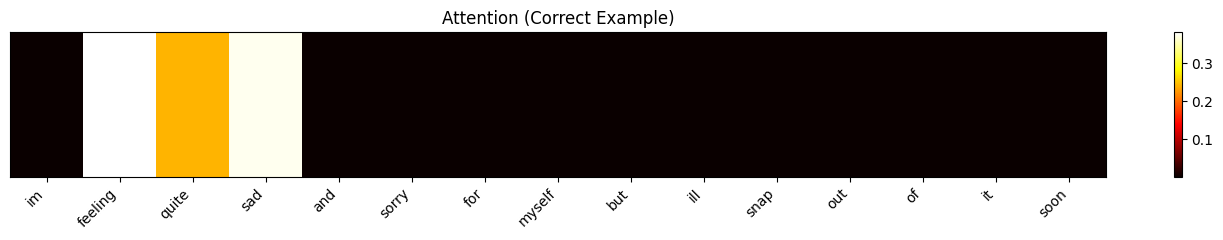


--- Wrong Example ---
True Label     : anger
Predicted Label: sadness


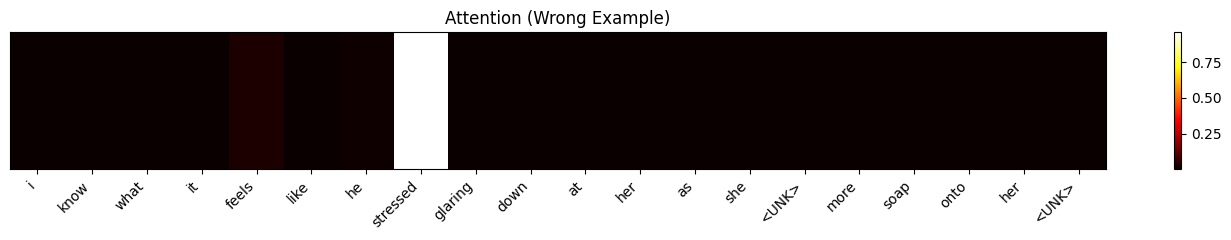

In [39]:
correct_example = get_example_from_loader(
    bilstm_attn_model, dev_loader, device, idx2word, want_correct=True
)

wrong_example = get_example_from_loader(
    bilstm_attn_model, dev_loader, device, idx2word, want_correct=False
)

label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

print("\n--- Correct Example ---")
print("True Label     :", label_names[correct_example["true_label"]])
print("Predicted Label:", label_names[correct_example["pred_label"]])

plot_attention_heatmap(correct_example["words"], correct_example["attn"],
                       title="Attention (Correct Example)")


print("\n--- Wrong Example ---")
print("True Label     :", label_names[wrong_example["true_label"]])
print("Predicted Label:", label_names[wrong_example["pred_label"]])

plot_attention_heatmap(wrong_example["words"], wrong_example["attn"],
                       title="Attention (Wrong Example)")


In [40]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [41]:
lstm_params = count_parameters(lstm_model)

print(f"BiLSTM Parameters: {lstm_params:,}")

BiLSTM Parameters: 1,564,286


In [42]:
birnn_params = count_parameters(birnn_model)

print(f"BiLSTM Parameters: {birnn_params:,}")

BiLSTM Parameters: 1,707,774


In [43]:
bilstmattn_params = count_parameters(bilstm_attn_model)

print(f"BiLSTM Parameters: {bilstmattn_params:,}")

BiLSTM Parameters: 1,623,806
